In [ ]:
import numpy as np
import gymnasium as gym
import importlib
import envs
from learners import *
from analysis import *

def get_exp_scheduler(alpha, n_ep_decay, min_val=0.005): return lambda t: max(alpha * 0.5**(t/n_ep_decay), min_val)

params = Params(
    model_name="CliffSlipperyLow",
    n_runs=1,
    n_episodes=10_000,
    save_skip=50,
    lr_decay=None,
    seed=123,
    
    N=64,
    alpha=1.0,
    gamma=0.99,
    epsilon=0.0,
    kappa=0.0,
    
    nA=None,
    nS=None,
    shape=None,
)
rng = np.random.default_rng(params.seed)
tau = (np.arange(params.N) + 0.5) / params.N
env = gym.make(params.model_name)
params = params._replace(nA=int(env.action_space.n))
params = params._replace(nS=int(env.observation_space.n))
params = params._replace(shape=env.unwrapped.shape)
s_init, _ = env.reset()

explorer = EpsilonGreedy(rng)

In [21]:
from tqdm import tqdm
import numpy as np
from typing import NamedTuple
import gymnasium as gym
import envs

class Params(NamedTuple):
    model_name: str
    n_runs: int  # Number of runs
    n_episodes: int  # Total episodes
    save_skip: int # How many episodes to skip between each save
    lr_decay: int # Half lr every lr_decay episodes
    seed: int # Define a seed so that we get reproducible results

    N: int # Number of quantiles
    alpha: float # Learning rate
    gamma: float # Discounting rate
    epsilon: float # Exploration probability
    
    nA: int # Number of possible actions
    nS: int # Number of possible states
    shape: tuple[int, int] # Size of the map (for gridworlds)


def HL_grad(u, kappa):
    return np.where(np.abs(u) <= kappa, u, kappa * np.sign(u))

def rho(Ttheta, theta, tau, kappa):
    u = Ttheta[:, None] - theta[None, :]
    
    if kappa == 0:
        return -(tau - (u < 0)).mean(0)
    else:
        return -(np.abs(tau - (u < 0)) * HL_grad(u, kappa)).mean(0)

def rho_manual(Ttheta, theta, tau, kappa):
    N = len(Ttheta)
    g = np.zeros(N)
    for i in range(N):
        for j in range(N):
            u_ji = Ttheta[j] - theta[i]
            I = tau[i] - (u_ji < 0).astype(float)
            if kappa == 0:
                g[i] += -I / N
            else:
                g[i] += -np.abs(I / N) * HL_grad(u_ji, kappa)
    return g

def rho_td(Ttheta, theta, *_args):
    return -(Ttheta - theta)

def train_qrtd(env, policy, params, kappa=0, rho_type=None):
    if rho_type == "manual": rho_func = rho_manual
    elif rho_type == "td": rho_func = rho_td
    else: rho_func = rho
    
    tau = (np.arange(params.N) + 0.5) / params.N
    nS = int(env.observation_space.n)
    table = np.zeros((params.n_runs, params.n_episodes//params.save_skip, nS, params.N))
    
    with tqdm(total=params.n_runs * params.n_episodes) as pbar:
        for run in range(params.n_runs):
            theta = np.zeros((nS, params.N))
            
            for ep in range(params.n_episodes):
                # lr = params.alpha**((1 + ep) // 2000)
                lr = (params.alpha[run%len(params.alpha)] if isinstance(params.alpha, list) else params.alpha) * 1/((1+0.5*ep)**0.5)#**0.66)
                s, _ = env.reset()
                done = False
                while not done:
                    sp, r, terminated, truncated, _ = env.step(policy[s].argmax())
                    done = terminated or truncated

                    Ttheta = (r + params.gamma * theta[sp])
                    theta[s] -= lr * rho_func(Ttheta, theta[s], tau, kappa)
                    s = sp
                
                if ep % params.save_skip == 0:
                    table[run, ep//params.save_skip] = theta.copy()
                pbar.set_postfix(run=run+1, ep=ep+1)
                pbar.update(1)
    return table

In [22]:
params = Params(
    model_name="CliffSlipperyLow",
    n_runs=1,
    n_episodes=100,
    save_skip=1,
    lr_decay=20,
    seed=123,

    N=64,
    alpha=0.5,
    gamma=0.99,
    epsilon=0.0,
    
    nA=None,
    nS=None,
    shape=None,
)
rng = np.random.default_rng(params.seed)
tau = (np.arange(params.N) + 0.5) / params.N
env = gym.make(params.model_name)
params = params._replace(nA=int(env.action_space.n))
params = params._replace(nS=int(env.observation_space.n))
params = params._replace(shape=env.unwrapped.shape)
s_init, _ = env.reset()

from learners import PolicyIteration
policy, _ = PolicyIteration(env, params.gamma)
table = train_qrtd(env, policy, params, 0, rho_type="manual")

100%|██████████| 100/100 [00:48<00:00,  2.05it/s, ep=100, run=1]


In [24]:
from learners import MonteCarlo
mc = MonteCarlo(env, policy, params.gamma)

100%|██████████| 5000/5000 [00:04<00:00, 1113.93it/s]


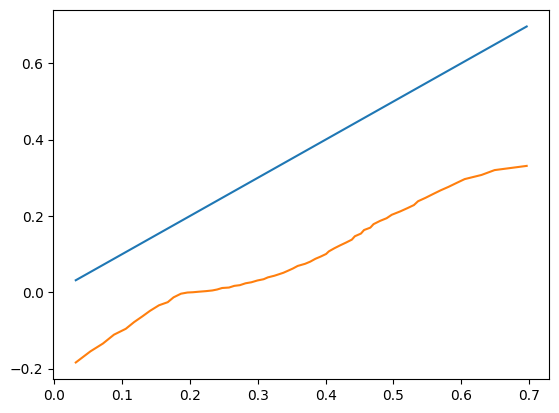

In [ ]:
from matplotlib import pyplot as plt
plt.plot(np.quantile(np.sort(mc), tau), np.quantile(np.sort(mc), tau))
plt.plot(np.quantile(np.sort(mc), tau), table[0,-1,s_init])

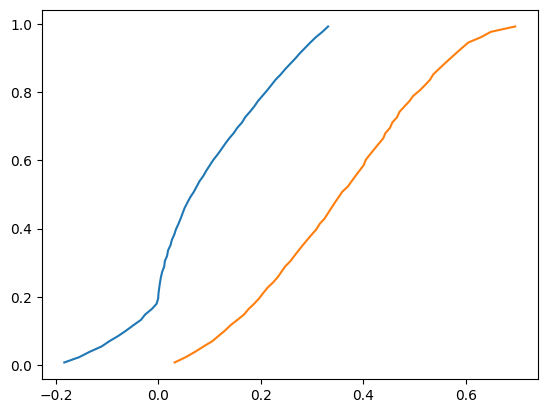

In [32]:
from matplotlib import pyplot as plt
plt.plot(table[0,-1,s_init], tau)
plt.plot(np.quantile(np.sort(mc), tau), tau)